In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [136]:
print(tf.__version__)



2.20.0


In [137]:
walking = pd.read_csv("walking.csv")
sleeping = pd.read_csv("sleeping.csv")

print("Walking:", walking.shape)
print("Sleeping:", sleeping.shape)

walking.head()


Walking: (368, 64)
Sleeping: (4251, 64)


,ax0,ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,...,gz4,gz5,gz6,gz7,gz8,gz9,ir,red,temp,time
0,2588,-14984,-13272,-11724,-11028,-11012,-11044,-10908,-10808,-10056,...,-2832,-3237,-3918,-4763,-5598,-6424,186926,66489,30.50,2026-01-07T15:25:24.700707747Z
1,32767,448,1128,2348,3900,6884,9408,12072,15272,17680,...,-10687,-10787,-10575,-10148,-9769,-9247,203807,93968,30.50,2026-01-07T15:25:29.409648504Z
2,-28068,-21192,-28460,-18232,-5384,-56,-8936,-15776,-15076,-6732,...,-5374,-1639,-3017,-7146,-10860,-11204,189078,93381,30.56,2026-01-07T15:25:33.078105129Z
3,-2040,-3596,-3764,-3832,-3892,-3756,-3660,-3612,-3368,-2992,...,-506,-510,-504,-534,-622,-650,200678,96920,30.50,2026-01-07T15:25:35.754861599Z
4,-2220,2920,2644,732,712,3536,6072,8088,10056,11768,...,-5716,-5842,-5817,-5738,-5552,-5146,202765,91904,30.50,2026-01-07T15:25:38.009049366Z


In [138]:
# Remove time column
walking = walking.drop(columns=["time"])
sleeping = sleeping.drop(columns=["time"])

# Add labels
walking["label"]  = 1   # walking
sleeping["label"] = 0   # sleeping


In [139]:
sleeping_balanced = sleeping.sample(
    n=len(walking),
    random_state=42
)

data = pd.concat([walking, sleeping_balanced], ignore_index=True)

# Keep numeric only
data = data.select_dtypes(include=[np.number])

print(data["label"].value_counts())


label
1    368
0    368
Name: count, dtype: int64


In [140]:
y = data["label"]
X_raw = data.drop(columns=["label"])


In [151]:
def build_stat_features(df):
    feats = {}

    # Accelerometer
    for axis in ["ax", "ay", "az"]:
        vals = df[[f"{axis}{i}" for i in range(10)]].values
        feats[f"{axis}_mean"] = np.nanmean(vals, axis=1)
        feats[f"{axis}_std"]  = np.nanstd(vals, axis=1)
        feats[f"{axis}_rms"]  = np.sqrt(np.nanmean(vals**2, axis=1))
        feats[f"{axis}_ptp"]  = np.nanmax(vals, axis=1) - np.nanmin(vals, axis=1)

    # Gyroscope (may have missing data)
    for axis in ["gx", "gy", "gz"]:
        vals = df[[f"{axis}{i}" for i in range(10)]].values
        feats[f"{axis}_std"] = np.nanstd(vals, axis=1)
        feats[f"{axis}_rms"] = np.sqrt(np.nanmean(vals**2, axis=1))

    return pd.DataFrame(feats)


In [152]:
X = build_stat_features(X_raw)

print("Feature shape:", X.shape)
X.head()


Feature shape: (736, 18)


,ax_mean,ax_std,ax_rms,ax_ptp,ay_mean,ay_std,ay_rms,ay_ptp,az_mean,az_std,az_rms,az_ptp,gx_std,gx_rms,gy_std,gy_rms,gz_std,gz_rms
0,-10224.8,4484.664286,11165.068240,17572,14024.4,4903.267629,14856.844510,17272,29157.5,10828.500000,31103.315233,36095,10172.108407,10310.657913,3582.783331,7271.858112,1991.545252,4423.747563
1,10190.7,9406.478109,13868.388403,32319,31605.3,2727.696723,31722.788615,9179,-12515.6,8697.610237,15241.019231,27860,8458.556695,25426.954808,8377.521326,19202.598600,1003.355789,10433.954677
2,-14791.2,9065.458629,17348.260362,28404,19231.4,10391.514146,21859.330095,30447,6779.1,14639.120031,16132.576735,47827,8884.667344,23762.745176,9233.331311,14563.131487,3718.939989,8601.153760
3,-3451.2,531.954284,3491.956013,1852,15390.4,747.013681,15408.518475,2592,-2562.0,886.324997,2710.980634,3252,1347.159237,6347.894840,815.744176,4627.271507,1013.298224,1351.232955
4,4430.8,4237.518160,6130.950073,13988,30949.2,4858.278971,31328.195850,16295,-11251.6,6836.632961,13165.791005,21896,6077.275725,24833.498078,4718.168586,10975.214864,1409.660743,5329.122620


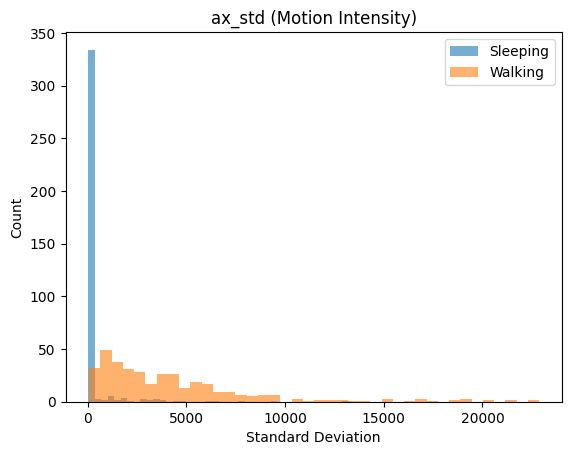

In [153]:
plt.figure()
plt.hist(X[y==0]["ax_std"], bins=40, alpha=0.6, label="Sleeping")
plt.hist(X[y==1]["ax_std"], bins=40, alpha=0.6, label="Walking")
plt.legend()
plt.title("ax_std (Motion Intensity)")
plt.xlabel("Standard Deviation")
plt.ylabel("Count")
plt.show()


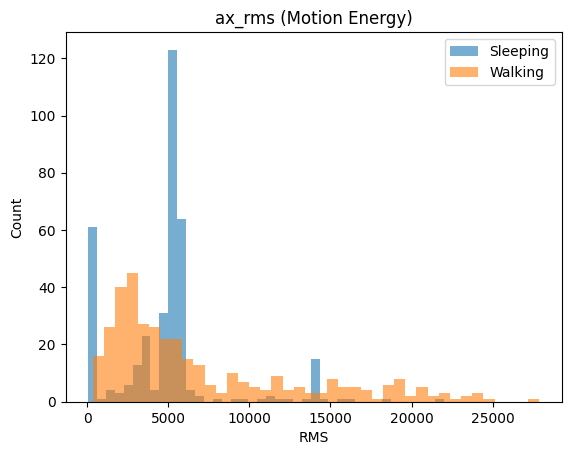

In [154]:
plt.figure()
plt.hist(X[y==0]["ax_rms"], bins=40, alpha=0.6, label="Sleeping")
plt.hist(X[y==1]["ax_rms"], bins=40, alpha=0.6, label="Walking")
plt.legend()
plt.title("ax_rms (Motion Energy)")
plt.xlabel("RMS")
plt.ylabel("Count")
plt.show()


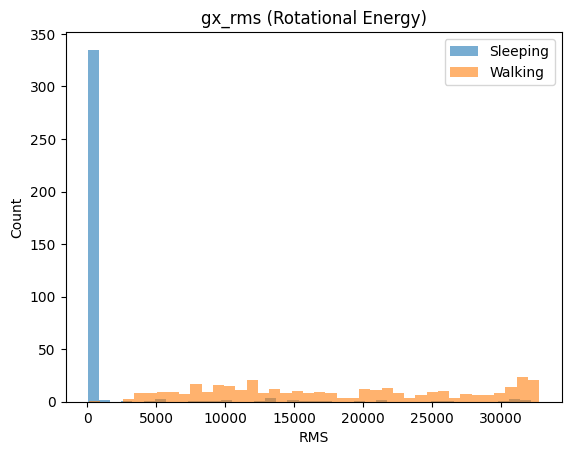

In [155]:
plt.figure()
plt.hist(X[y==0]["gx_rms"], bins=40, alpha=0.6, label="Sleeping")
plt.hist(X[y==1]["gx_rms"], bins=40, alpha=0.6, label="Walking")
plt.legend()
plt.title("gx_rms (Rotational Energy)")
plt.xlabel("RMS")
plt.ylabel("Count")
plt.show()


/tmp/ipykernel_5390/788117851.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


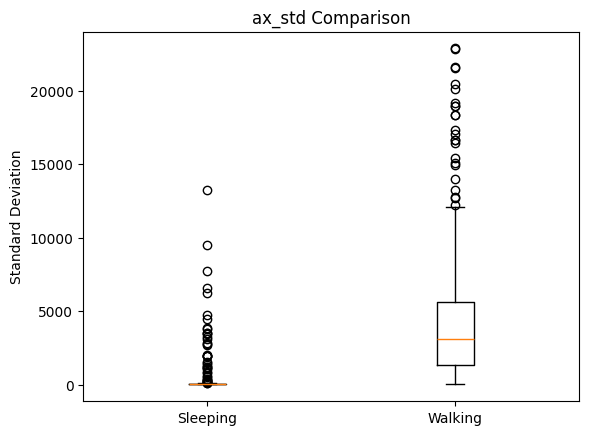

In [156]:
plt.figure()
plt.boxplot(
    [X[y==0]["ax_std"], X[y==1]["ax_std"]],
    labels=["Sleeping", "Walking"]
)
plt.title("ax_std Comparison")
plt.ylabel("Standard Deviation")
plt.show()


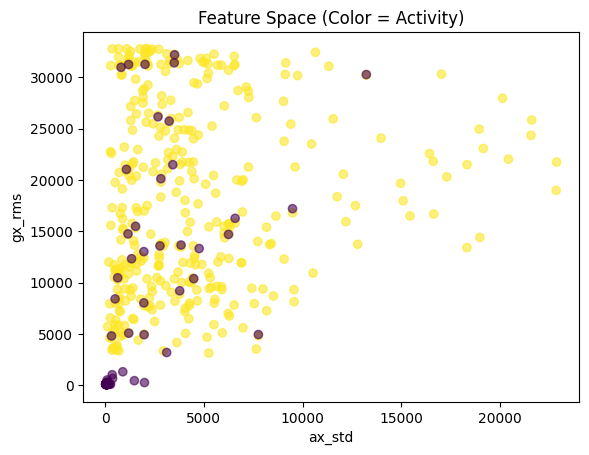

In [157]:
plt.figure()
plt.scatter(X["ax_std"], X["gx_rms"], c=y, alpha=0.6)
plt.xlabel("ax_std")
plt.ylabel("gx_rms")
plt.title("Feature Space (Color = Activity)")
plt.show()


In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [159]:
y_train_cat = keras.utils.to_categorical(y_train, 2)
y_test_cat  = keras.utils.to_categorical(y_test, 2)


In [161]:
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


ValueError: Classification metrics can't handle a mix of binary and multilabel-indicator targets

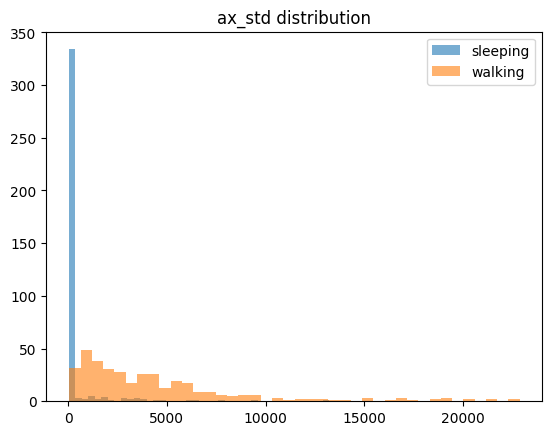

,mean,std
ax_mean,-2433.608016,5883.850511
ax_std,2350.647071,3781.490888
ax_rms,5922.898510,5025.383533
ax_ptp,7670.809783,11784.288593
ay_mean,11727.941984,10303.357674
ay_std,2049.010535,2544.099411
ay_rms,12674.927466,9679.626717
ay_ptp,6866.142663,8457.648869
az_mean,-3405.917120,12138.757804
az_std,3121.735707,4837.925292


In [162]:
import matplotlib.pyplot as plt

# Pick the MOST important feature
plt.hist(X[y == 0]["ax_std"], bins=40, alpha=0.6, label="sleeping")
plt.hist(X[y == 1]["ax_std"], bins=40, alpha=0.6, label="walking")
plt.legend()
plt.title("ax_std distribution")
plt.show()
X.describe().T[["mean", "std"]]


In [163]:
X.describe().T[["mean", "std"]]


,mean,std
ax_mean,-2433.608016,5883.850511
ax_std,2350.647071,3781.490888
ax_rms,5922.898510,5025.383533
ax_ptp,7670.809783,11784.288593
ay_mean,11727.941984,10303.357674
ay_std,2049.010535,2544.099411
ay_rms,12674.927466,9679.626717
ay_ptp,6866.142663,8457.648869
az_mean,-3405.917120,12138.757804
az_std,3121.735707,4837.925292


In [164]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_pred_lr = clf.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       1.00      0.93      0.97        74
           1       0.94      1.00      0.97        74

    accuracy                           0.97       148
   macro avg       0.97      0.97      0.97       148
weighted avg       0.97      0.97      0.97       148

[[69  5]
 [ 0 74]]


In [165]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("activity_model.tflite", "wb") as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: /tmp/tmpzysy9nse/assets


INFO:tensorflow:Assets written to: /tmp/tmpzysy9nse/assets


Saved artifact at '/tmp/tmpzysy9nse'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 18), dtype=tf.float32, name='keras_tensor_64')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  125457270664720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125457270665680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125457270665488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125457270663568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125457270666256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125457270665872: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1767843954.055425    5390 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1767843954.055438    5390 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-01-08 09:15:54.055542: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpzysy9nse
2026-01-08 09:15:54.055912: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-01-08 09:15:54.055918: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpzysy9nse
2026-01-08 09:15:54.058694: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-01-08 09:15:54.074099: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpzysy9nse
2026-01-08 09:15:54.079304: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 23763 microseconds.


In [166]:
y_train_cat = keras.utils.to_categorical(y_train, num_classes=2)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=2)


In [167]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(2, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 16)             │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458 (1.79 KB)

 Trainable params: 458 (1.79 KB)

 Non-trainable params: 0 (0.00 B)

In [168]:
history = model.fit(
    X_train_scaled,
    y_train_cat,
    epochs=40,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5043 - loss: 0.7238 - val_accuracy: 0.5678 - val_loss: 0.5871
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6255 - loss: 0.5298 - val_accuracy: 0.7034 - val_loss: 0.4879
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7979 - loss: 0.4451 - val_accuracy: 0.8136 - val_loss: 0.4313
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8745 - loss: 0.3887 - val_accuracy: 0.8814 - val_loss: 0.3849
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9064 - loss: 0.3351 - val_accuracy: 0.8898 - val_loss: 0.3438
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9170 - loss: 0.2873 - val_accuracy: 0.8898 - val_loss: 0.3088
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9234 - loss: 0.2468 - val_accuracy: 0.8898 - val_loss: 0.2841
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9298 - loss: 0.2199 - val_accuracy: 0.9068 - val_los

In [169]:
y_pred = model.predict(X_test_scaled).argmax(axis=1)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
ax_std(walking)  >>  ax_std(sleeping)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        74
           1       0.91      1.00      0.95        74

    accuracy                           0.95       148
   macro avg       0.96      0.95      0.95       148
weighted avg       0.96      0.95      0.95       148

[[67  7]
 [ 0 74]]


NameError: name 'ax_std' is not defined

In [134]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_pred_lr = clf.predict(X_test_scaled)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))



ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values